# Healthcare Billing Anomaly Detection using Autoencoders

Anomaly detection is used to find unusual patterns in data. In healthcare billing data, unusual financial behavior can indicate inefficiencies, inconsistencies, or even potential fraud. Since the data is nonlinear and high-dimensional, traditional statistical methods often struggle to capture complex patterns. This is why deep learning methods are useful for detecting hidden anomalies in such data.

This project uses autoencoder neural networks to detect anomalies in inpatient hospital charges. Autoencoders learn normal patterns in the data and identify anomalies based on reconstruction error. The workflow includes data preprocessing, feature engineering, exploratory data analysis, model building, anomaly detection, and visualization. Different autoencoder models are tested to compare their performance. 

The autoencoder models are implemented using TensorFlow and Keras, which provide tools for building and training neural networks.

In [1145]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

The dataset used in this project is the Inpatient Hospital Charges dataset from Kaggle. It contains healthcare billing information for inpatient services across hospitals in different U.S. states. Key variables include DRG Definition, Provider State, Total Discharges, Average Covered Charges, Average Total Payments, and Average Medicare Payments.

This dataset is suitable for anomaly detection because healthcare billing data is highly variable and skewed. This makes it challenging for traditional methods, so unsupervised deep learning techniques are useful for identifying unusual billing patterns.

In [1148]:
df = pd.read_csv("inpatientCharges.csv")

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

df.head()

Dataset Shape: (163065, 12)

Column Names:

['DRG Definition', 'Provider Id', 'Provider Name', 'Provider Street Address', 'Provider City', 'Provider State', 'Provider Zip Code', 'Hospital Referral Region Description', 'Total Discharges', 'Average Covered Charges', 'Average Total Payments', 'Average Medicare Payments']


,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,$32963.07,$5777.24,$4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,$15131.85,$5787.57,$4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,$37560.37,$5434.95,$4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,$13998.28,$5417.56,$4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,$31633.27,$5658.33,$4851.44


## Data Cleaning

The dataset is checked for duplicates, and currency-formatted columns are converted into numeric format by removing symbols like dollar signs and commas.

In [1151]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:\n")
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163065 entries, 0 to 163064
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype 
---  ------                                --------------   ----- 
 0   DRG Definition                        163065 non-null  object
 1   Provider Id                           163065 non-null  int64 
 2   Provider Name                         163065 non-null  object
 3   Provider Street Address               163065 non-null  object
 4   Provider City                         163065 non-null  object
 5   Provider State                        163065 non-null  object
 6   Provider Zip Code                     163065 non-null  int64 
 7   Hospital Referral Region Description  163065 non-null  object
 8   Total Discharges                      163065 non-null  int64 
 9   Average Covered Charges               163065 non-null  object
 10  Average Total Payments                163065 non-null  object
 11  Average Medic

,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
count,163065,163065.000000,163065,163065,163065,163065,163065.000000,163065,163065.000000,163065,163065,163065
unique,100,NaN,3201,3326,1977,51,NaN,306,NaN,160236,147842,150328
top,194 - SIMPLE PNEUMONIA & PLEURISY W CC,NaN,GOOD SAMARITAN HOSPITAL,100 MEDICAL CENTER DRIVE,CHICAGO,CA,NaN,CA - Los Angeles,NaN,$31155.00,$4370.00,$4908.00
freq,3023,NaN,633,183,1505,13064,NaN,3653,NaN,4,9,5
mean,NaN,255569.865428,NaN,NaN,NaN,NaN,47938.121908,NaN,42.776304,NaN,NaN,NaN
std,NaN,151563.671767,NaN,NaN,NaN,NaN,27854.323080,NaN,51.104042,NaN,NaN,NaN
min,NaN,10001.000000,NaN,NaN,NaN,NaN,1040.000000,NaN,11.000000,NaN,NaN,NaN
25%,NaN,110092.000000,NaN,NaN,NaN,NaN,27261.000000,NaN,17.000000,NaN,NaN,NaN
50%,NaN,250007.000000,NaN,NaN,NaN,NaN,44309.000000,NaN,27.000000,NaN,NaN,NaN
75%,NaN,380075.000000,NaN,NaN,NaN,NaN,72901.000000,NaN,49.000000,NaN,NaN,NaN


In [1152]:
# Remove duplicates
df = df.drop_duplicates()

# Clean currency columns
currency_cols = [
    'Average Covered Charges',
    'Average Total Payments',
    'Average Medicare Payments'
]

for col in currency_cols:
    df[col] = (
        df[col]
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )

## Feature Engineering

Ten new features are created from the original dataset to improve anomaly detection. These features capture financial irregularities, regional differences, and unusual billing behaviour in healthcare charges.

In [1155]:
# 1 Charge to Medicare Ratio
df['Charge_to_Medicare_Ratio'] = (
    df['Average Covered Charges'] /
    (df['Average Medicare Payments'] + 1)
)

# 2 Payment Gap
df['Payment_Gap'] = (
    df['Average Covered Charges'] -
    df['Average Medicare Payments']
)

# 3 Payment Gap Ratio
df['Payment_Gap_Ratio'] = (
    df['Payment_Gap'] /
    (df['Average Covered Charges'] + 1)
)

# 4 Charge per Discharge
df['Charge_per_Discharge'] = (
    df['Average Covered Charges'] /
    (df['Total Discharges'] + 1)
)

# 5 Log Charges
df['Log_Covered_Charges'] = np.log1p(
    df['Average Covered Charges']
)

# 6 Log Medicare Payments
df['Log_Medicare_Payments'] = np.log1p(
    df['Average Medicare Payments']
)

# 7 Z-score Charges
df['Charge_Zscore'] = (
    (df['Average Covered Charges'] -
     df['Average Covered Charges'].mean()) /
    df['Average Covered Charges'].std()
)

# 8 State Average Charge
state_avg = df.groupby('Provider State')[
    'Average Covered Charges'
].transform('mean')

df['State_Charge_Deviation'] = (
    df['Average Covered Charges'] - state_avg
)

# 9 DRG Frequency
drg_freq = df['DRG Definition'].value_counts()

df['DRG_Frequency'] = df['DRG Definition'].map(drg_freq)

# 10 Regional Cost Ratio
df['Regional_Cost_Ratio'] = (
    df['Average Covered Charges'] /
    (state_avg + 1)
)

### Financial Ratio Features

##### Charge_to_Medicare_Ratio

This feature is calculated as the ratio of Average Covered Charges to Average Medicare Payments. It helps identify cases where hospital charges are disproportionately high compared to Medicare reimbursements, which may indicate overbilling or abnormal pricing behaviour.

##### Payment_Gap

This feature is computed as the difference between Average Covered Charges and Average Medicare Payments. It captures the absolute gap between billed amounts and reimbursements, helping to highlight records with unusually large financial differences.

##### Payment_Gap_Ratio

This feature normalizes the payment gap by dividing it by Average Covered Charges. It allows comparison across hospitals with different billing scales and helps detect relative inconsistencies in charges versus payments.

##### Charge_per_Discharge

This feature is calculated by dividing Average Covered Charges by Total Discharges. It represents the average cost per patient discharge and helps detect providers with unusually high per-patient billing behaviour.

### Log and Statistical Features

##### Log_Covered_Charges

This feature applies a logarithmic transformation to Average Covered Charges. It reduces skewness in the data and makes extreme values more distinguishable, improving anomaly detection performance.

##### Log_Medicare_Payments

This feature applies a logarithmic transformation to Average Medicare Payments. It helps stabilize the distribution and improves the model’s ability to detect outliers in financial values.

##### Charge_Zscore

This feature standardizes Average Covered Charges using z-score normalization. It measures how far each value deviates from the mean in terms of standard deviations, helping identify unusual billing amounts.

### Regional and Frequency-Based Features

##### State_Charge_Deviation

This feature measures the difference between a provider’s charges and the average charges within the same state. It helps detect providers that deviate from typical regional pricing behavior.

##### DRG_Frequency

This feature represents how frequently each DRG category appears in the dataset. Rare DRG categories may indicate unusual medical procedures or abnormal billing patterns.

##### Regional_Cost_Ratio

This feature compares provider charges with the average charges at the state level. It helps identify hospitals that are significantly more expensive compared to regional norms.


In [1159]:
df.head()

,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,...,Charge_to_Medicare_Ratio,Payment_Gap,Payment_Gap_Ratio,Charge_per_Discharge,Log_Covered_Charges,Log_Medicare_Payments,Charge_Zscore,State_Charge_Deviation,DRG_Frequency,Regional_Cost_Ratio
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,32963.07,...,6.918140,28199.34,0.855457,358.294239,10.403173,8.468996,-0.090428,1646.607926,1079,1.052546
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,15131.85,...,3.039922,10155.14,0.671066,1008.790000,9.624623,8.512725,-0.598942,-16184.612074,1079,0.483176
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,37560.37,...,8.431457,33106.58,0.881400,1502.414800,10.533731,8.401735,0.040679,6243.907926,1079,1.199343
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,13998.28,...,3.389283,9869.12,0.704973,538.395385,9.546761,8.326071,-0.631269,-17318.182074,1079,0.446980
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,31633.27,...,6.519044,26781.83,0.846608,1664.908947,10.361996,8.487237,-0.128351,316.807926,1079,1.010084


In [1161]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['Provider Id', 'Provider Zip Code', 'Total Discharges',
       'Average Covered Charges', 'Average Total Payments',
       'Average Medicare Payments', 'Charge_to_Medicare_Ratio', 'Payment_Gap',
       'Payment_Gap_Ratio', 'Charge_per_Discharge', 'Log_Covered_Charges',
       'Log_Medicare_Payments', 'Charge_Zscore', 'State_Charge_Deviation',
       'DRG_Frequency', 'Regional_Cost_Ratio'],
      dtype='object')


## Exploratory Data Analysis on Original and Engineered Features

EDA is performed to analyze feature distributions, identify outliers, and understand relationships between variables before model building. Both original and engineered features are used to better understand healthcare billing patterns and evaluate how well the new features capture unusual behaviour.

Engineered features show clearer separation between normal and anomalous records compared to original features. They also reduce skewness and make extreme values more distinguishable, which improves the visibility of unusual patterns in the data.

### Distribution Plots on Original Features

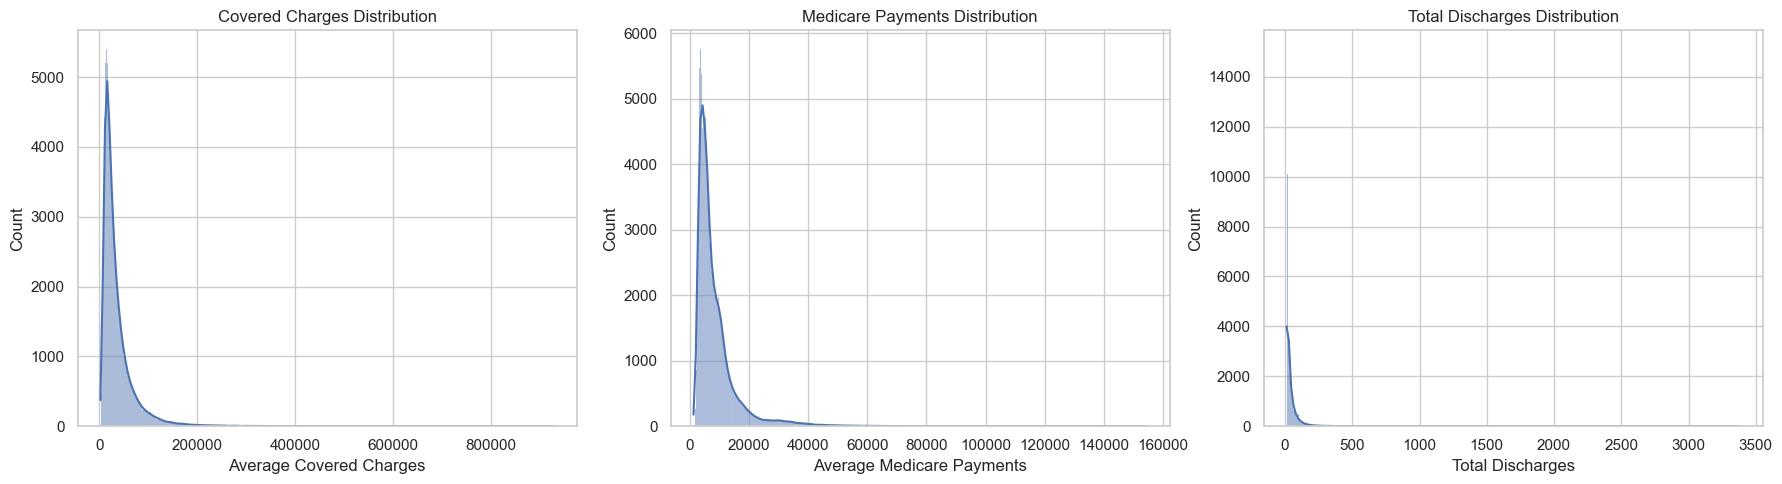

In [1165]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Average Covered Charges'], kde=True, ax=axes[0])
axes[0].set_title('Covered Charges Distribution')

sns.histplot(df['Average Medicare Payments'], kde=True, ax=axes[1])
axes[1].set_title('Medicare Payments Distribution')

sns.histplot(df['Total Discharges'], kde=True, ax=axes[2])
axes[2].set_title('Total Discharges Distribution')

plt.tight_layout()
plt.show()

The histograms for Average Covered Charges, Average Medicare Payments, and Total Discharges show a strong right-skewed distribution. Most providers have values clustered at lower ranges, while a small number of providers show very high values, forming a long tail on the right side of each distribution.

### Box Plots on Original Features

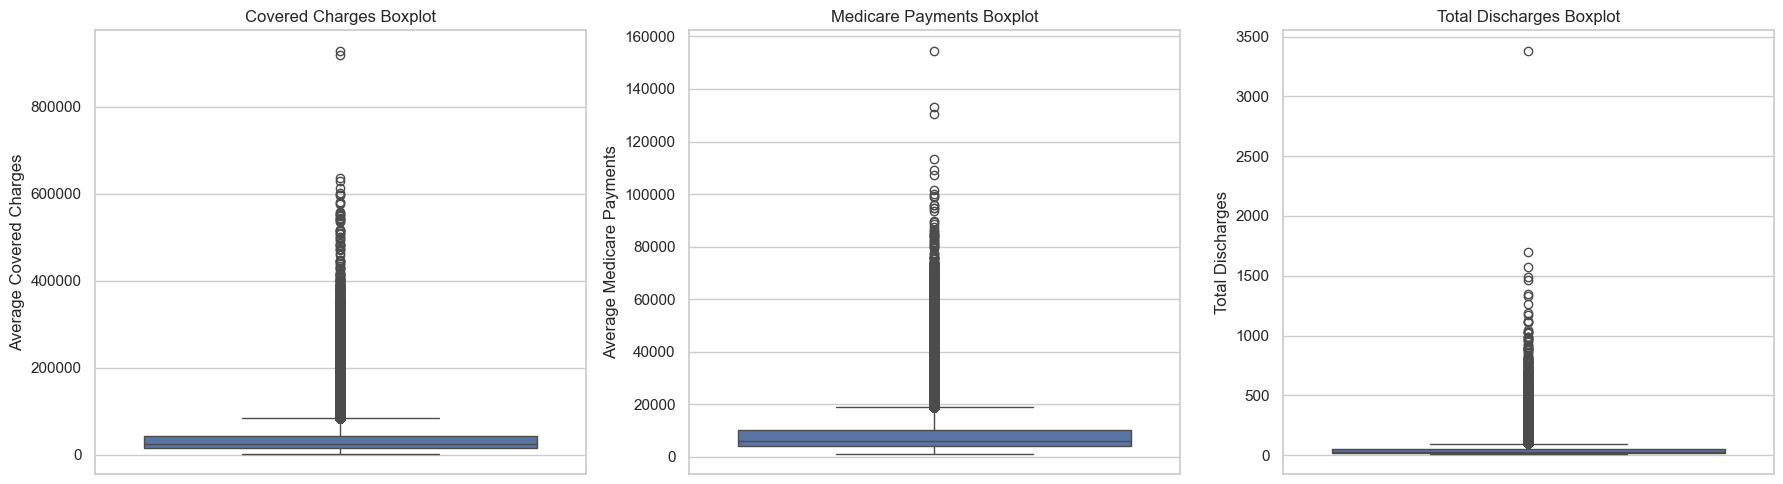

In [1168]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(y=df['Average Covered Charges'], ax=axes[0])
axes[0].set_title('Covered Charges Boxplot')

sns.boxplot(y=df['Average Medicare Payments'], ax=axes[1])
axes[1].set_title('Medicare Payments Boxplot')

sns.boxplot(y=df['Total Discharges'], ax=axes[2])
axes[2].set_title('Total Discharges Boxplot')

plt.tight_layout()
plt.show()

The boxplots clearly show the presence of many outliers in all three original variables. Most of the data is concentrated within a narrow range, while several points lie beyond the upper whiskers, representing providers with unusually high charges and payment values compared to the rest of the dataset.

### Scatter Plots on Original Features

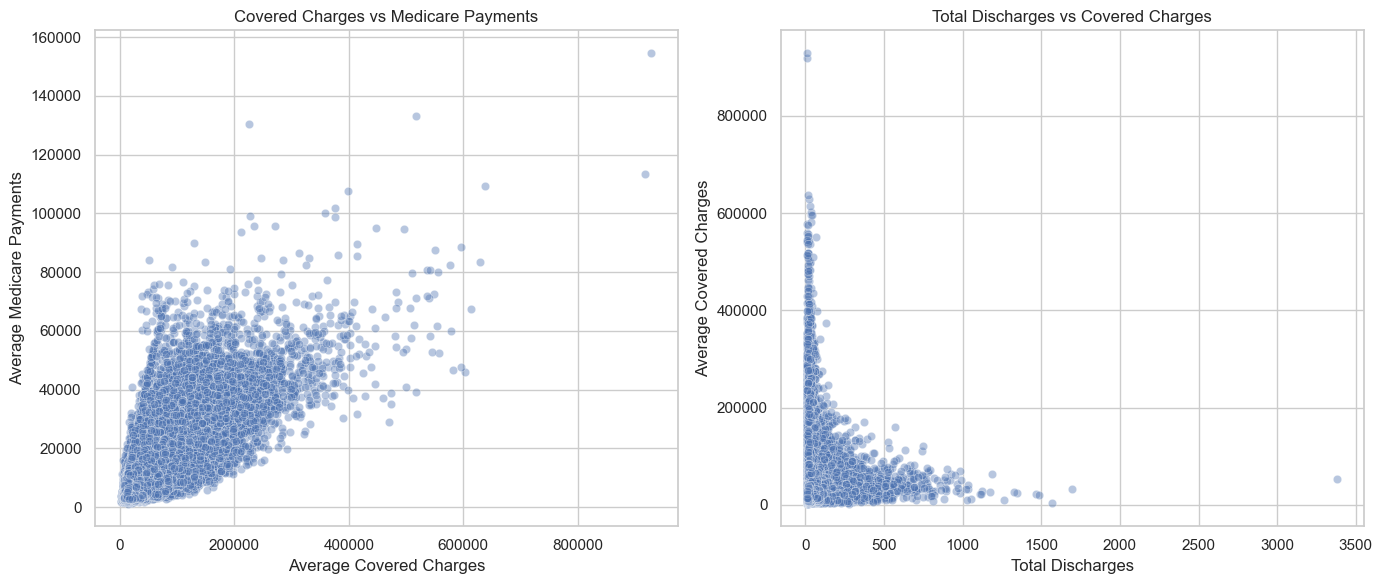

In [1173]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Covered Charges vs Medicare Payments
sns.scatterplot(
    x=df['Average Covered Charges'],
    y=df['Average Medicare Payments'],
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("Covered Charges vs Medicare Payments")

# Total Discharges vs Covered Charges
sns.scatterplot(
    x=df['Total Discharges'],
    y=df['Average Covered Charges'],
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title("Total Discharges vs Covered Charges")

plt.tight_layout()
plt.show()

The scatter plot between Average Covered Charges and Average Medicare Payments shows a positive relationship, indicating that higher billing amounts are associated with higher payments, although the relationship is not perfectly linear and shows noticeable variation. The relationship between Total Discharges and Covered Charges suggests that higher charges are not necessarily driven by higher patient volume. Some hospitals with relatively few discharges still report very high covered charges, indicating that billing intensity plays a stronger role than patient volume in certain cases.


### Statewise Charge Analysis

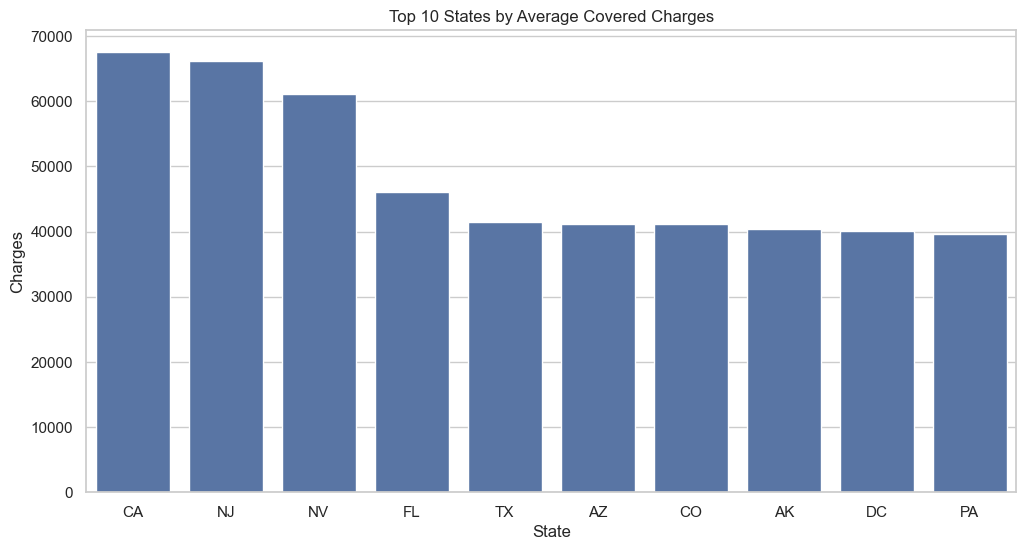

In [1176]:
top_states = (
    df.groupby('Provider State')['Average Covered Charges']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top 10 States by Average Covered Charges")
plt.xlabel("State")
plt.ylabel("Charges")

plt.show()

The bar plot of state-wise averages shows clear differences in healthcare charges across regions. States such as California (CA) and New Jersey (NJ) have higher average covered charges compared to other states. This indicates that what is considered a normal charge in one state may appear as an outlier when compared across different regions..

### Distribution Plots on Engineered Features

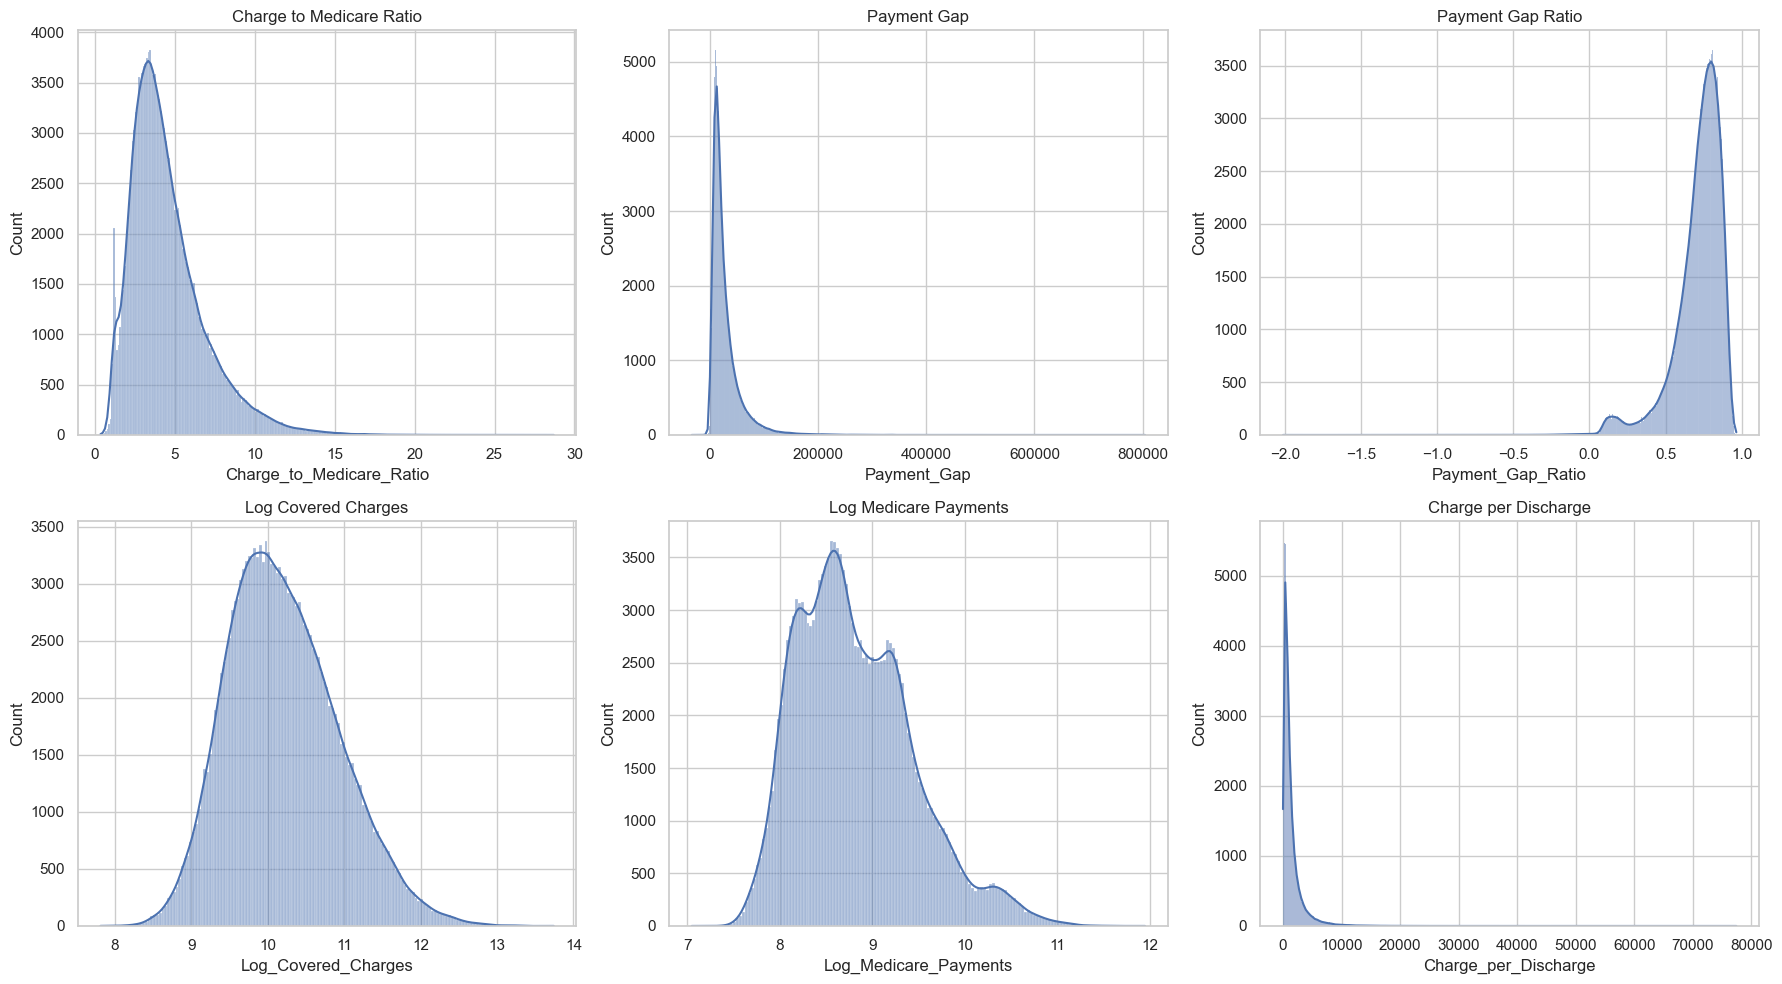

In [1181]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

sns.histplot(df['Charge_to_Medicare_Ratio'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Charge to Medicare Ratio')

sns.histplot(df['Payment_Gap'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Payment Gap')

sns.histplot(df['Payment_Gap_Ratio'], kde=True, ax=axes[0,2])
axes[0,2].set_title('Payment Gap Ratio')

sns.histplot(df['Log_Covered_Charges'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Log Covered Charges')

sns.histplot(df['Log_Medicare_Payments'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Log Medicare Payments')

sns.histplot(df['Charge_per_Discharge'], kde=True, ax=axes[1,2])
axes[1,2].set_title('Charge per Discharge')

plt.tight_layout()
plt.show()

The distribution plots for features such as Charge_to_Medicare_Ratio and Payment_Gap show that the data remains heavily right-skewed. This indicates that most providers operate within a stable billing range, while a small number show extreme financial behavior, forming a long tail. However, log-transformed variables such as Log_Covered_Charges and Log_Medicare_Payments help reduce skewness and produce a more balanced distribution. This improves variance stability and makes it easier to distinguish between normal billing patterns and extreme values. Payment_Gap_Ratio shows a strong concentration at lower values, indicating that for most providers, the proportional difference between billed and paid amounts is relatively small and consistent.


### Boxplots on Engineered Features

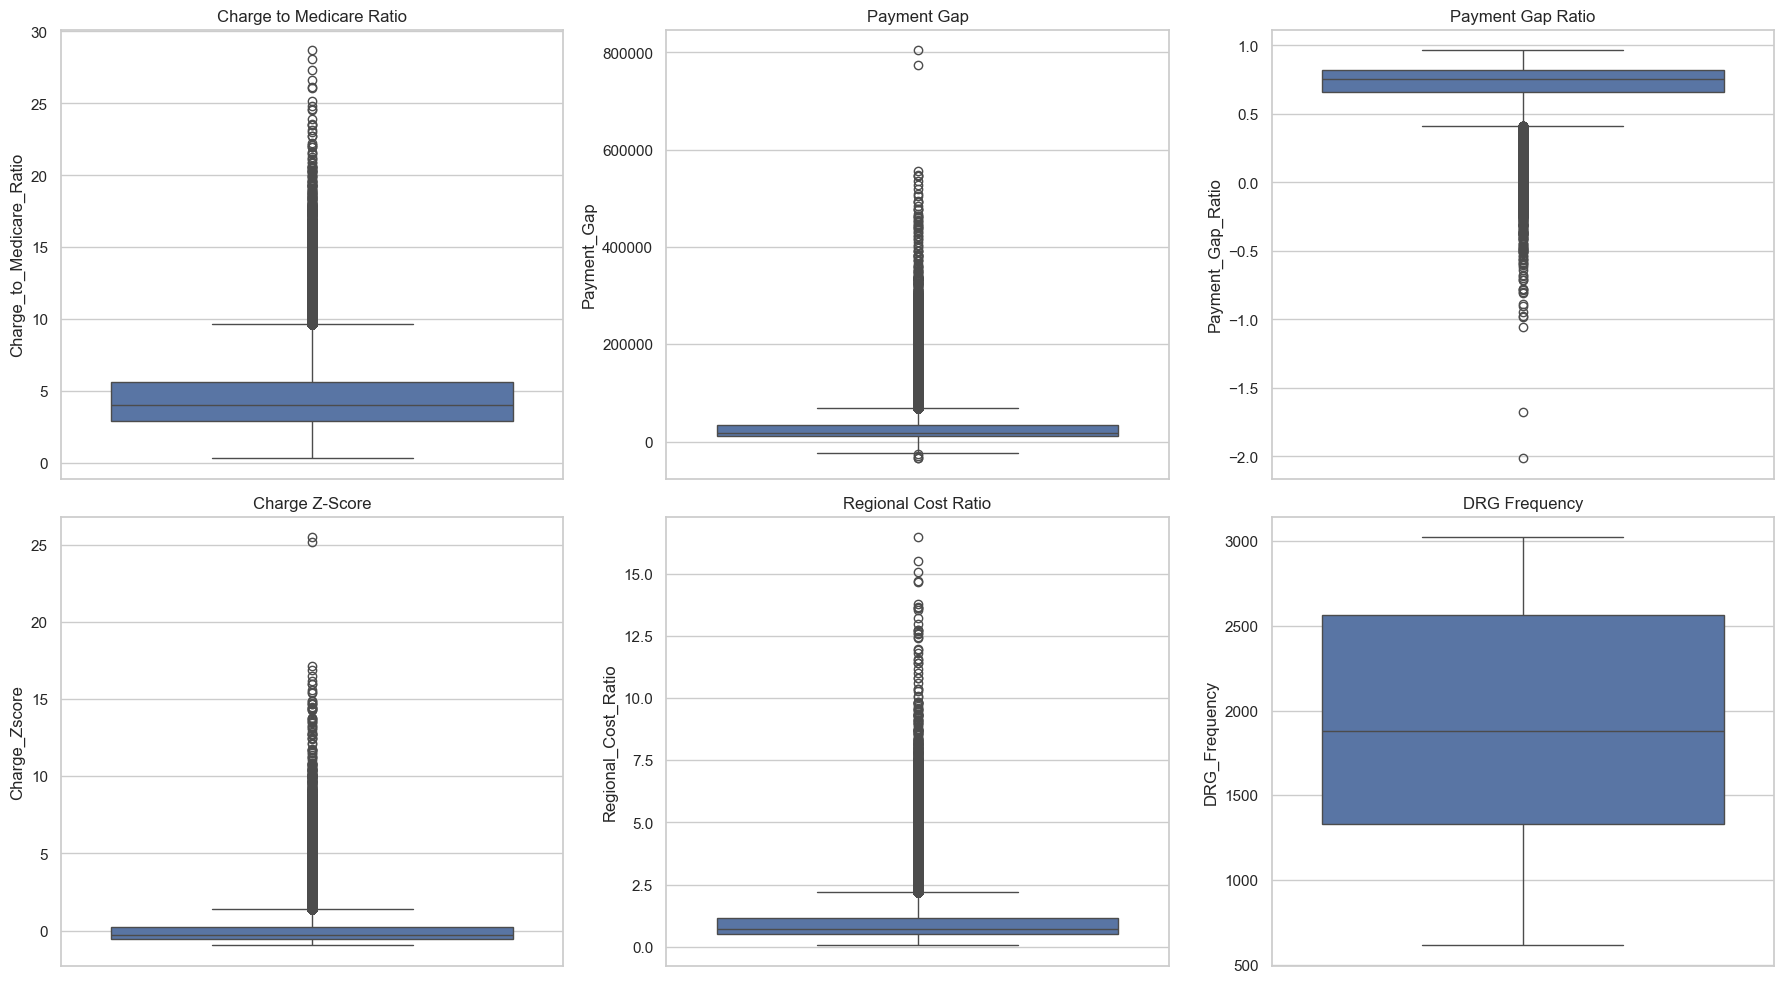

In [1185]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

sns.boxplot(y=df['Charge_to_Medicare_Ratio'], ax=axes[0,0])
axes[0,0].set_title('Charge to Medicare Ratio')

sns.boxplot(y=df['Payment_Gap'], ax=axes[0,1])
axes[0,1].set_title('Payment Gap')

sns.boxplot(y=df['Payment_Gap_Ratio'], ax=axes[0,2])
axes[0,2].set_title('Payment Gap Ratio')

sns.boxplot(y=df['Charge_Zscore'], ax=axes[1,0])
axes[1,0].set_title('Charge Z-Score')

sns.boxplot(y=df['Regional_Cost_Ratio'], ax=axes[1,1])
axes[1,1].set_title('Regional Cost Ratio')

sns.boxplot(y=df['DRG_Frequency'], ax=axes[1,2])
axes[1,2].set_title('DRG Frequency')

plt.tight_layout()
plt.show()

The boxplots provide clear visual evidence of abnormal behavior across multiple financial features. Charge_Zscore and Regional_Cost_Ratio show several points far beyond the upper whiskers, representing providers whose charges are significantly higher than both overall and regional averages. Payment_Gap also shows a wider spread compared to other features, highlighting greater variation in billing differences. In addition, DRG_Frequency shows strong imbalance, where a small number of procedures occur very frequently while many are rare. These rare categories are important because they are more likely to contain irregular or inconsistent billing behavior.

### Distribution of DRG Procedure Frequencies (Top 10 Categories)

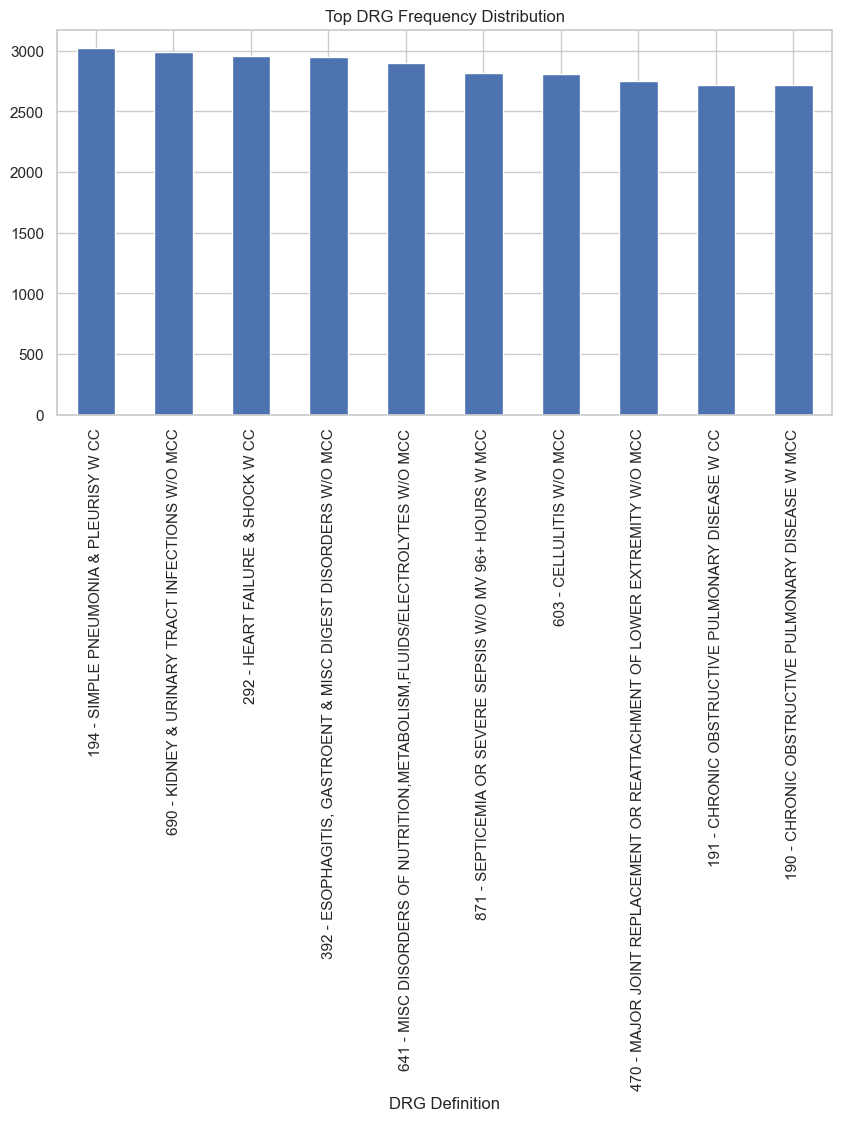

In [1189]:
plt.figure(figsize=(10,5))

df['DRG Definition'].value_counts().head(10).plot(kind='bar')

plt.title("Top DRG Frequency Distribution")
plt.show()

The DRG frequency distribution identifies the most common medical procedures such as pneumonia, heart failure, and infections. These high-frequency procedures form a stable baseline of normal healthcare activity, as they provide many consistent examples for the model to learn from. Because these procedures are common, their billing patterns are relatively predictable. When features such as Charge_to_Medicare_Ratio or Payment_Gap show unusually high values within these common procedures, they stand out more clearly as anomalies compared to rare procedures, which naturally have higher variability.

### Correlation Heatmap of Dataset Features

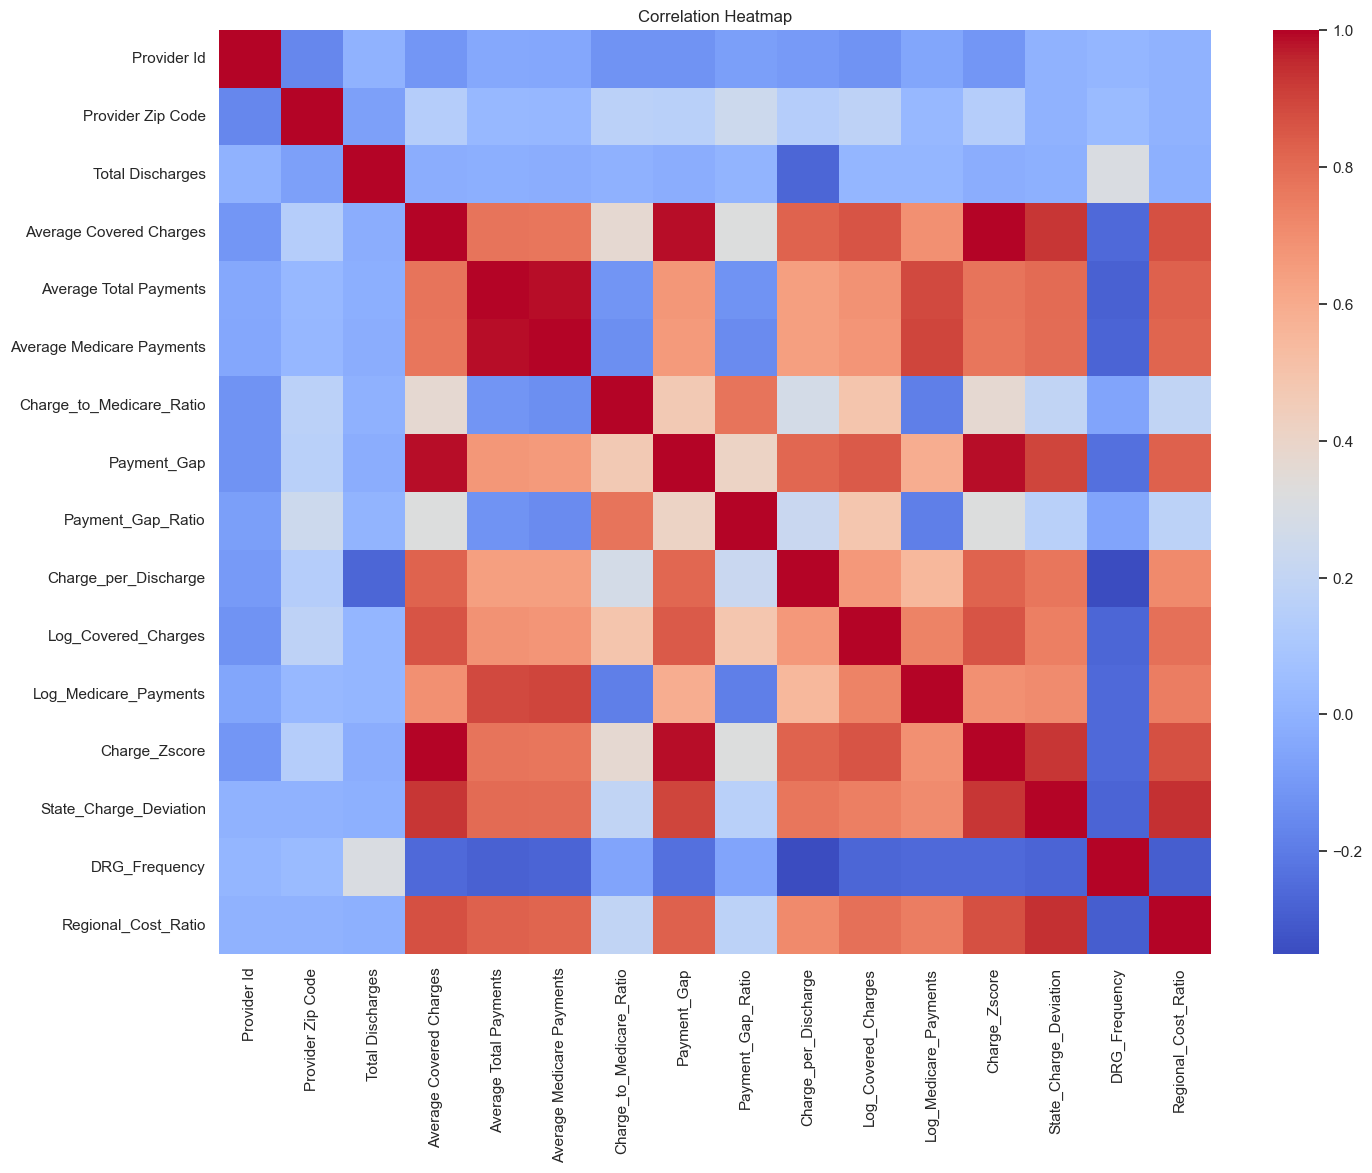

In [1193]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between original and engineered features in the dataset. Strong positive correlations are observed between financial variables such as Average Covered Charges and Average Medicare Payments, as well as engineered features like Payment_Gap, Charge_Zscore, and Log_Covered_Charges, indicating that they retain similar underlying patterns in transformed forms.

High correlation is also seen between Average Total Payments and Average Medicare Payments, suggesting overlapping information. Log-transformed features remain strongly correlated with their original versions while reducing skewness.

DRG_Frequency shows negative correlation with some financial features, while administrative variables such as Provider Zip Code and Provider Id show very weak correlation with billing-related features. Regional_Cost_Ratio shows moderate correlation with major financial variables, reflecting alignment with overall billing trends while incorporating regional variation.

## Train Test Split

The dataset is split into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [1198]:
X_train, X_test = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (130452, 22)
Test Shape: (32613, 22)


## Encoding Categorical Variables

Categorical variables such as DRG Definition, Provider State, Provider Name, and Hospital Referral Region Description are encoded using a combination of one-hot encoding and frequency encoding. One-hot encoding is applied to low-cardinality features, while frequency encoding is used for high-cardinality features to reduce dimensionality while preserving distribution information.

In [1202]:
categorical_cols = X_train.select_dtypes(include='object').columns

# One-hot for low-cardinality feature
one_hot_cols = [
    c for c in categorical_cols
    if X_train[c].nunique() <= 50 and c == "Provider State"
]


# frequency encoding
freq_cols = [c for c in categorical_cols if c not in one_hot_cols]

for c in freq_cols:
    freq = X_train[c].value_counts(normalize=True)

    X_train[c] = X_train[c].map(freq)
    X_test[c] = X_test[c].map(freq).fillna(0)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

if len(one_hot_cols) > 0:
    train_ohe = ohe.fit_transform(X_train[one_hot_cols])
    test_ohe = ohe.transform(X_test[one_hot_cols])

    ohe_cols = ohe.get_feature_names_out(one_hot_cols)

    train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=X_train.index)
    test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_cols, index=X_test.index)

    X_train = X_train.drop(columns=one_hot_cols)
    X_test = X_test.drop(columns=one_hot_cols)

    X_train = pd.concat([X_train, train_ohe_df], axis=1)
    X_test = pd.concat([X_test, test_ohe_df], axis=1)


X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

## Feature Scaling

StandardScaler is fitted on the training data and then used to transform both the training and testing sets to avoid data leakage and ensure consistent scaling.

In [1206]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)


## Autoencoders

Autoencoders are unsupervised neural networks used to learn compressed representations of data and reconstruct the original input. The model consists of two parts: an encoder and a decoder. The encoder compresses the input into a lower-dimensional representation, and the decoder reconstructs the original data from this compressed form.

The bottleneck layer forces the model to retain only the most important information needed for reconstruction. During training, the model learns patterns from normal data by minimizing reconstruction error. As a result, normal records are reconstructed well, while unusual records that do not follow learned patterns produce higher reconstruction error.

Reconstruction error is used to identify anomalies. Lower error indicates normal behaviour, while higher error indicates deviation from learned patterns and suggests potential anomalies.

Three autoencoder variants are used in this project. The first is a basic autoencoder with ReLU activation. The second uses deeper hidden layers to capture more complex relationships. The third uses Tanh activation to compare performance with ReLU-based models.


## Model Development and Training

All models are trained using the Adam optimizer with Mean Squared Error (MSE) as the loss function. Adam adjusts learning rates automatically to improve convergence speed and stability. Early stopping is used to prevent overfitting by monitoring validation loss and restoring the best model weights.

### MODEL 1: BASIC AUTOENCODER

The basic autoencoder uses a simple encoder-decoder structure with a small latent space and ReLU activation. It focuses on learning general patterns in the data without increasing model complexity. This model serves as a baseline for comparison.

In [1214]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder_1 = Model(inputs=input_layer, outputs=decoded)

autoencoder_1.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder_1.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_180 (Dense)               │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_185 (Dense)               │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,166 (31.90 KB)

 Trainable params: 8,166 (31.90 KB)

 Non-trainable params: 0 (0.00 B)

### Training Model 1

In [1217]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_1 = autoencoder_1.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0751 - val_loss: 0.0111
Epoch 2/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 3/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0042 - val_loss: 0.0027
Epoch 4/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 5/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 6/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0016 - val_loss: 8.4997e-04
Epoch 7/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0013 - val_loss: 6.3684e-04
Epoch 8/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0010 - val_loss: 5.0625e-04
Epoch 9/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 8.7942e-04 - val_loss: 4.1411e-04
Epoch 10/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.9757e-04 - val_loss: 3.5800e-04
Epoch 11/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6.9426e-04 - val_loss: 3.201

### Model 1 Loss Curve

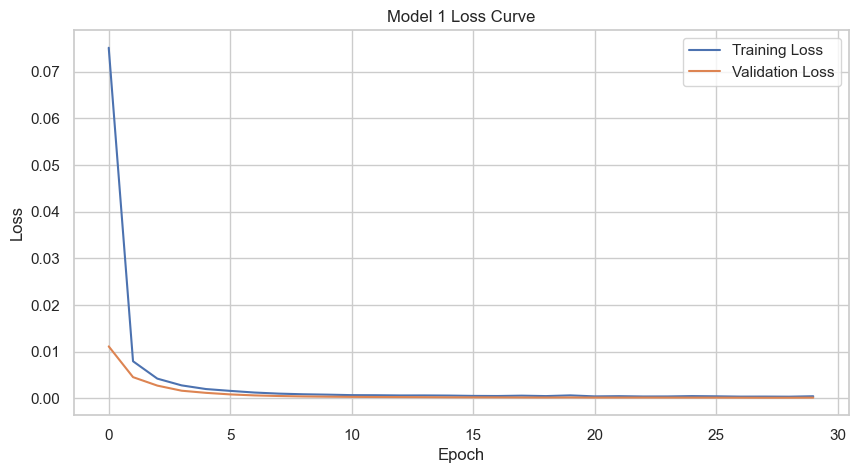

In [1220]:
plt.figure(figsize=(10,5))

plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')

plt.title("Model 1 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

The loss curve for the Basic Autoencoder shows how the model learns over 30 epochs. Both training and validation loss decrease quickly in the first few epochs, showing that the model learns the main patterns in the data early.

After the initial drop, both curves become stable and remain close to each other throughout training. The small gap between training and validation loss indicates that the model is not overfitting and is performing similarly on unseen data.

The consistently low validation loss shows that the model is able to reconstruct normal records with good accuracy. Because of this, reconstruction error from this model can be used to identify records that behave differently from normal patterns.

### MODEL 2 : DEEP AUTOENCODER

The deep autoencoder includes additional hidden layers compared to the basic model. This increases its ability to learn complex nonlinear relationships between features. However, higher complexity can also make the model more sensitive to noise.

In [1225]:
input_layer2 = Input(shape=(input_dim,))

encoded2 = Dense(128, activation='relu')(input_layer2)
encoded2 = Dense(64, activation='relu')(encoded2)
encoded2 = Dense(32, activation='relu')(encoded2)
encoded2 = Dense(16, activation='relu')(encoded2)

decoded2 = Dense(32, activation='relu')(encoded2)
decoded2 = Dense(64, activation='relu')(decoded2)
decoded2 = Dense(128, activation='relu')(decoded2)
decoded2 = Dense(input_dim, activation='linear')(decoded2)

autoencoder_2 = Model(inputs=input_layer2, outputs=decoded2)

autoencoder_2.compile(
    optimizer='adam',
    loss='mse'
)

history_2 = autoencoder_2.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0806 - val_loss: 0.0114
Epoch 2/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0100 - val_loss: 0.0059
Epoch 3/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0061 - val_loss: 0.0039
Epoch 4/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0044 - val_loss: 0.0029
Epoch 5/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0037 - val_loss: 0.0023
Epoch 6/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0031 - val_loss: 0.0019
Epoch 7/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0027 - val_loss: 0.0016
Epoch 8/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 9/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 10/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0020 - val_loss: 0.0011


### Model 2 Loss Curve

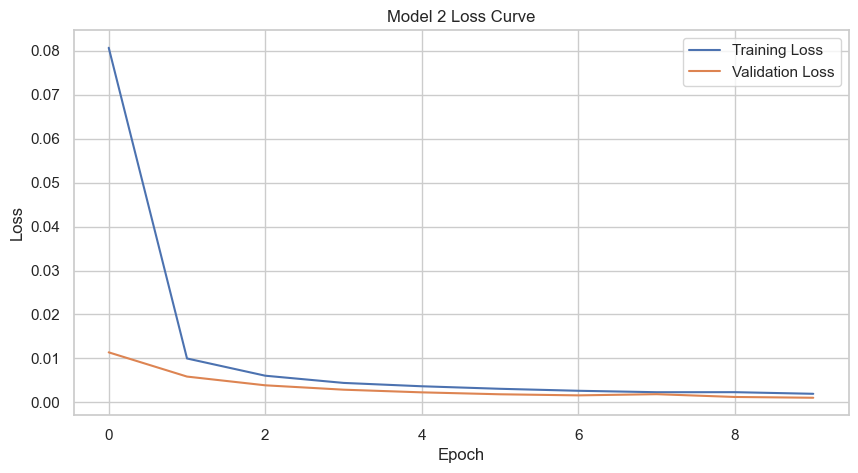

In [1228]:
plt.figure(figsize=(10,5))

plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')

plt.title("Model 2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

The Deep Autoencoder shows a sharp decrease in training loss in the first epoch, followed by a gradual reduction over the remaining epochs. This indicates that the model quickly learns the main patterns in the data and then continues to refine its weights.

The validation loss follows a similar trend and remains close to the training loss throughout training, indicating stable learning behavior. No major fluctuations are observed in either curve.

The final loss is higher compared to the Basic Autoencoder, indicating lower reconstruction accuracy for this dataset. The model still captures general data patterns, but the simpler model generalizes better on this tabular dataset, while the deeper model adds unnecessary complexity.

### MODEL 3 : TANH ACTIVATION AUTOENCODER

The Tanh autoencoder uses the same architecture as the deep model but replaces ReLU activation with the Tanh function. Tanh outputs values between -1 and 1, allowing the model to capture both positive and negative relationships in the data. This model is used to compare how activation functions affect reconstruction performance.

In [1233]:
input_layer3 = Input(shape=(input_dim,))

encoded3 = Dense(64, activation='tanh')(input_layer3)
encoded3 = Dense(32, activation='tanh')(encoded3)
encoded3 = Dense(16, activation='tanh')(encoded3)

decoded3 = Dense(32, activation='tanh')(encoded3)
decoded3 = Dense(64, activation='tanh')(decoded3)
decoded3 = Dense(input_dim, activation='linear')(decoded3)

autoencoder_3 = Model(inputs=input_layer3, outputs=decoded3)

autoencoder_3.compile(
    optimizer='adam',
    loss='mse'
)

history_3 = autoencoder_3.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0824 - val_loss: 0.0199
Epoch 2/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0163 - val_loss: 0.0082
Epoch 3/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0104 - val_loss: 0.0056
Epoch 4/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0083 - val_loss: 0.0043
Epoch 5/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0073 - val_loss: 0.0037
Epoch 6/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0067 - val_loss: 0.0033
Epoch 7/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 8/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0057 - val_loss: 0.0026
Epoch 9/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - val_loss: 0.0024
Epoch 10/30
1631/1631 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0052 - val_loss: 0.0023


### Model 3 Loss Curve

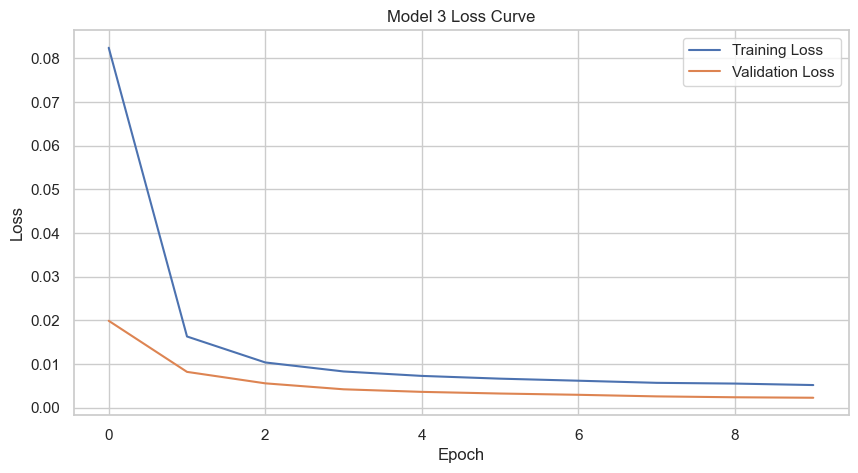

In [1235]:
plt.figure(figsize=(10,5))

plt.plot(history_3.history['loss'], label='Training Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')

plt.title("Model 3 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

The Tanh Autoencoder shows a steady decrease in training loss across 10 epochs, with a sharp drop in the first two epochs followed by a gradual decline.

The validation loss follows a similar downward trend and stays close to the training loss, indicating consistent behavior during training. No major fluctuations are observed in either curve.

The final loss remains higher compared to the Basic and Deep Autoencoder models, indicating lower reconstruction accuracy for this dataset. The model still learns general patterns in normal records, but with less precision compared to the other models.

## Model Comparison

In [1246]:
comparison_df = pd.DataFrame({
    'Model': [
        'Basic Autoencoder',
        'Deep Autoencoder',
        'Tanh Autoencoder'
    ],
    'Final Training Loss': [
        min(history_1.history['loss']),
        min(history_2.history['loss']),
        min(history_3.history['loss'])
    ],
    'Final Validation Loss': [
        min(history_1.history['val_loss']),
        min(history_2.history['val_loss']),
        min(history_3.history['val_loss'])
    ]
})

comparison_df

,Model,Final Training Loss,Final Validation Loss
0,Basic Autoencoder,0.000363,0.000134
1,Deep Autoencoder,0.001968,0.001070
2,Tanh Autoencoder,0.005224,0.002320


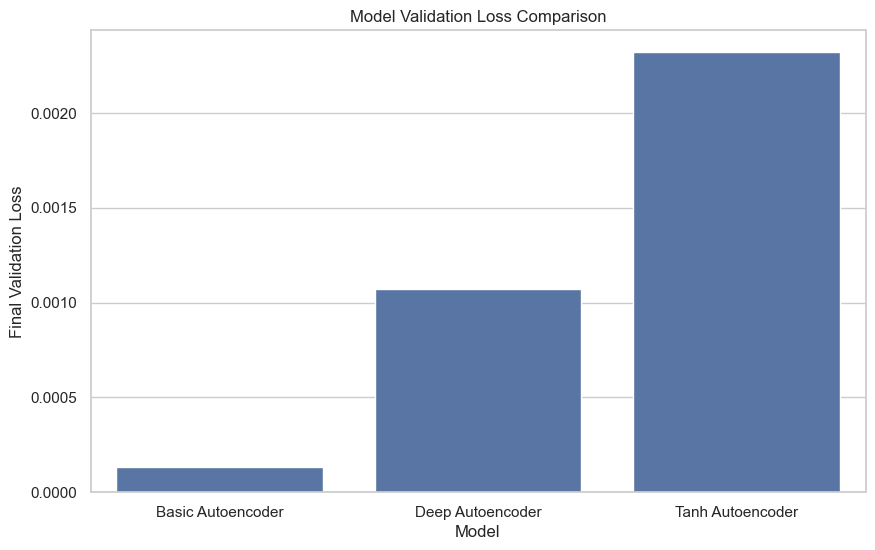

In [1248]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Final Validation Loss',
    data=comparison_df
)

plt.title("Model Validation Loss Comparison")

plt.show()

The performance of the three autoencoder models is compared using final training loss and validation loss. The Basic Autoencoder shows the lowest training loss (0.000363) and validation loss (0.000134), indicating better reconstruction accuracy compared to the other models. The Deep Autoencoder has higher training and validation loss values, while the Tanh Autoencoder records the highest losses among the three models.

Based on validation loss performance, the Basic Autoencoder is selected for anomaly detection because it achieves the lowest validation loss and provides the best reconstruction of the input data compared to the other architectures.

## Reconstruction Errors

In [1252]:
reconstructions = autoencoder_1.predict(X_test)

mse = np.mean(
    np.power(X_test - reconstructions, 2),
    axis=1
)

error_df = pd.DataFrame({
    'Reconstruction_Error': mse
})

error_df.head()

1020/1020 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


,Reconstruction_Error
0,0.000264
1,0.000228
2,0.000049
3,0.000157
4,0.000140


Reconstruction error is computed for the test data using the trained autoencoder. The model reconstructs each input sample, and the difference between original and reconstructed values is measured using Mean Squared Error (MSE), calculated across all features for each record.

Each record is assigned a reconstruction error score, which is used in later steps to identify unusual observations.

## Threshold Selection

In [1267]:
threshold = np.percentile(
    error_df['Reconstruction_Error'],
    99
)

print("Threshold:", threshold)

Threshold: 0.0009631044222372532


The threshold for identifying anomalies is set using the 99th percentile of the reconstruction error distribution. This means that only the top 1% of records with the highest reconstruction error are considered as potential anomalies.

The 99th percentile is used to ensure that most normal records are retained while only extreme deviations from normal behavior are flagged. This approach is suitable for anomaly detection tasks where anomalies are rare and expected to lie in the extreme tail of the error distribution.

The computed threshold value is 0.0009631044222372532.

## Anomaly Detection

In [1271]:
error_df['Anomaly'] = (
    error_df['Reconstruction_Error'] > threshold
).astype(int)

anomaly_count = error_df['Anomaly'].sum()

total_count = len(error_df)

anomaly_percentage = (
    anomaly_count / total_count
) * 100

print("Total Records:", total_count)
print("Anomalies Detected:", anomaly_count)
print("Anomaly Percentage:", round(anomaly_percentage,2), "%")

Total Records: 32613
Anomalies Detected: 327
Anomaly Percentage: 1.0 %


Anomalies are identified by comparing reconstruction error values with the selected threshold. Records with reconstruction error greater than the threshold are classified as anomalies, while the rest are considered normal.

Each record in the test dataset is assigned a binary label (0 for normal and 1 for anomaly). The total number of records is 32,613, out of which 327 records are identified as anomalies.

This corresponds to an anomaly percentage of 1.0%, indicating that only a small fraction of the data shows unusual reconstruction behavior compared to normal patterns.

#### Total Records: 32,613 | Anomalies Detected: 327 | Anomaly Percentage: 1.0%

## Reconstruction Error Distribution

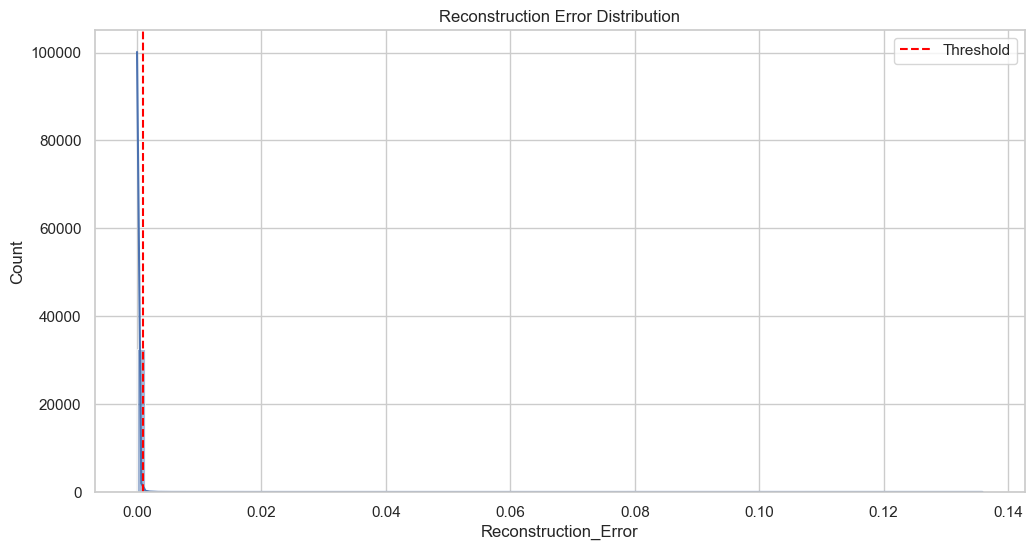

In [1275]:
plt.figure(figsize=(12,6))

sns.histplot(
    error_df['Reconstruction_Error'],
    bins=100,
    kde=True
)

plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.title("Reconstruction Error Distribution")
plt.legend()

plt.show()

The reconstruction error distribution plot shows that most values are concentrated very close to zero. This indicates that the majority of records are reconstructed with very small error by the autoencoder.

The distribution is highly right-skewed, with a small number of records showing higher reconstruction errors compared to the main cluster.

The threshold (0.0009631044222372532.) is used to separate normal and anomalous records. Values below the threshold are considered normal, while values above it are flagged as anomalies.

This separation ensures that only records with relatively high reconstruction error are identified as abnormal compared to the majority of the dataset.

## Feature-Level Analysis of Anomalies (Normal vs Anomalous Records)

Feature-wise statistics are analyzed to justify anomaly detection using data attributes. This helps identify how anomalous records differ from normal records in terms of underlying financial and structural features

In [1279]:
X_test_with_anomaly = X_test.copy()

X_test_with_anomaly['Reconstruction_Error'] = error_df['Reconstruction_Error']
X_test_with_anomaly['Anomaly'] = error_df['Anomaly']

In [1281]:
numeric_features = [
    'Total Discharges',
    'Average Covered Charges',
    'Average Total Payments',
    'Average Medicare Payments',
    'Charge_to_Medicare_Ratio',
    'Payment_Gap',
    'Payment_Gap_Ratio',
    'Charge_per_Discharge',
    'Log_Covered_Charges',
    'Log_Medicare_Payments',
    'Charge_Zscore',
    'State_Charge_Deviation',
    'DRG_Frequency',
    'Regional_Cost_Ratio'
]

In [1283]:
normal = X_test_with_anomaly[X_test_with_anomaly['Anomaly'] == 0]
anomaly = X_test_with_anomaly[X_test_with_anomaly['Anomaly'] == 1]

In [1285]:
comparison = pd.DataFrame({
    'Feature': numeric_features,
    'Normal_Mean': normal[numeric_features].mean().values,
    'Anomaly_Mean': anomaly[numeric_features].mean().values,
})

comparison['Difference'] = comparison['Anomaly_Mean'] - comparison['Normal_Mean']
comparison['Abs_Difference'] = comparison['Difference'].abs()

comparison = comparison.sort_values('Abs_Difference', ascending=False)

comparison

,Feature,Normal_Mean,Anomaly_Mean,Difference,Abs_Difference
2,Average Total Payments,-0.027320,2.532699,2.560019,2.560019
3,Average Medicare Payments,-0.027255,2.495310,2.522565,2.522565
13,Regional_Cost_Ratio,-0.023090,1.981797,2.004887,2.004887
11,State_Charge_Deviation,-0.023600,1.957001,1.980600,1.980600
10,Charge_Zscore,-0.020256,1.905344,1.925600,1.925600
1,Average Covered Charges,-0.020256,1.905344,1.925600,1.925600
7,Charge_per_Discharge,-0.011456,1.758904,1.770361,1.770361
5,Payment_Gap,-0.017156,1.630444,1.647599,1.647599
9,Log_Medicare_Payments,-0.012924,1.379638,1.392562,1.392562
6,Payment_Gap_Ratio,0.013466,-1.059001,-1.072466,1.072466


Anomalous records show consistently higher values across multiple financial and derived features compared to normal records, indicating a clear shift in billing behavior.

The largest differences are seen in Average Total Payments, Average Medicare Payments, and Average Covered Charges, indicating that high-cost billing is a major characteristic of anomalous cases.

Strong deviations are also present in State_Charge_Deviation and Regional_Cost_Ratio, showing that anomalous records are not only high in absolute billing amounts but also differ significantly from state-level and regional pricing patterns.

Features such as Charge_Zscore and Payment_Gap show clear separation between normal and anomalous records, indicating that anomalies are associated with both statistical deviation from the dataset mean and large differences between billed and reimbursed amounts.

Log-transformed engineered features (Log_Covered_Charges and Log_Medicare_Payments) also remain higher for anomalous records, confirming that extreme values persist even after reducing skewness in the data.

In contrast, DRG_Frequency and Total Discharges show smaller but noticeable differences, indicating that anomalies are not driven only by procedure frequency or patient volume, but by a combination of financial intensity and pricing deviations.

Overall, the consistent differences across both financial and derived features indicate clear abnormal billing patterns in the anomalous records.

In [1288]:
top_features = comparison.head(8)['Feature'].tolist()

print(top_features)

['Average Total Payments', 'Average Medicare Payments', 'Regional_Cost_Ratio', 'State_Charge_Deviation', 'Charge_Zscore', 'Average Covered Charges', 'Charge_per_Discharge', 'Payment_Gap']


##### Box plots are used to compare the distribution of selected features between normal and anomalous records to better understand their differences.

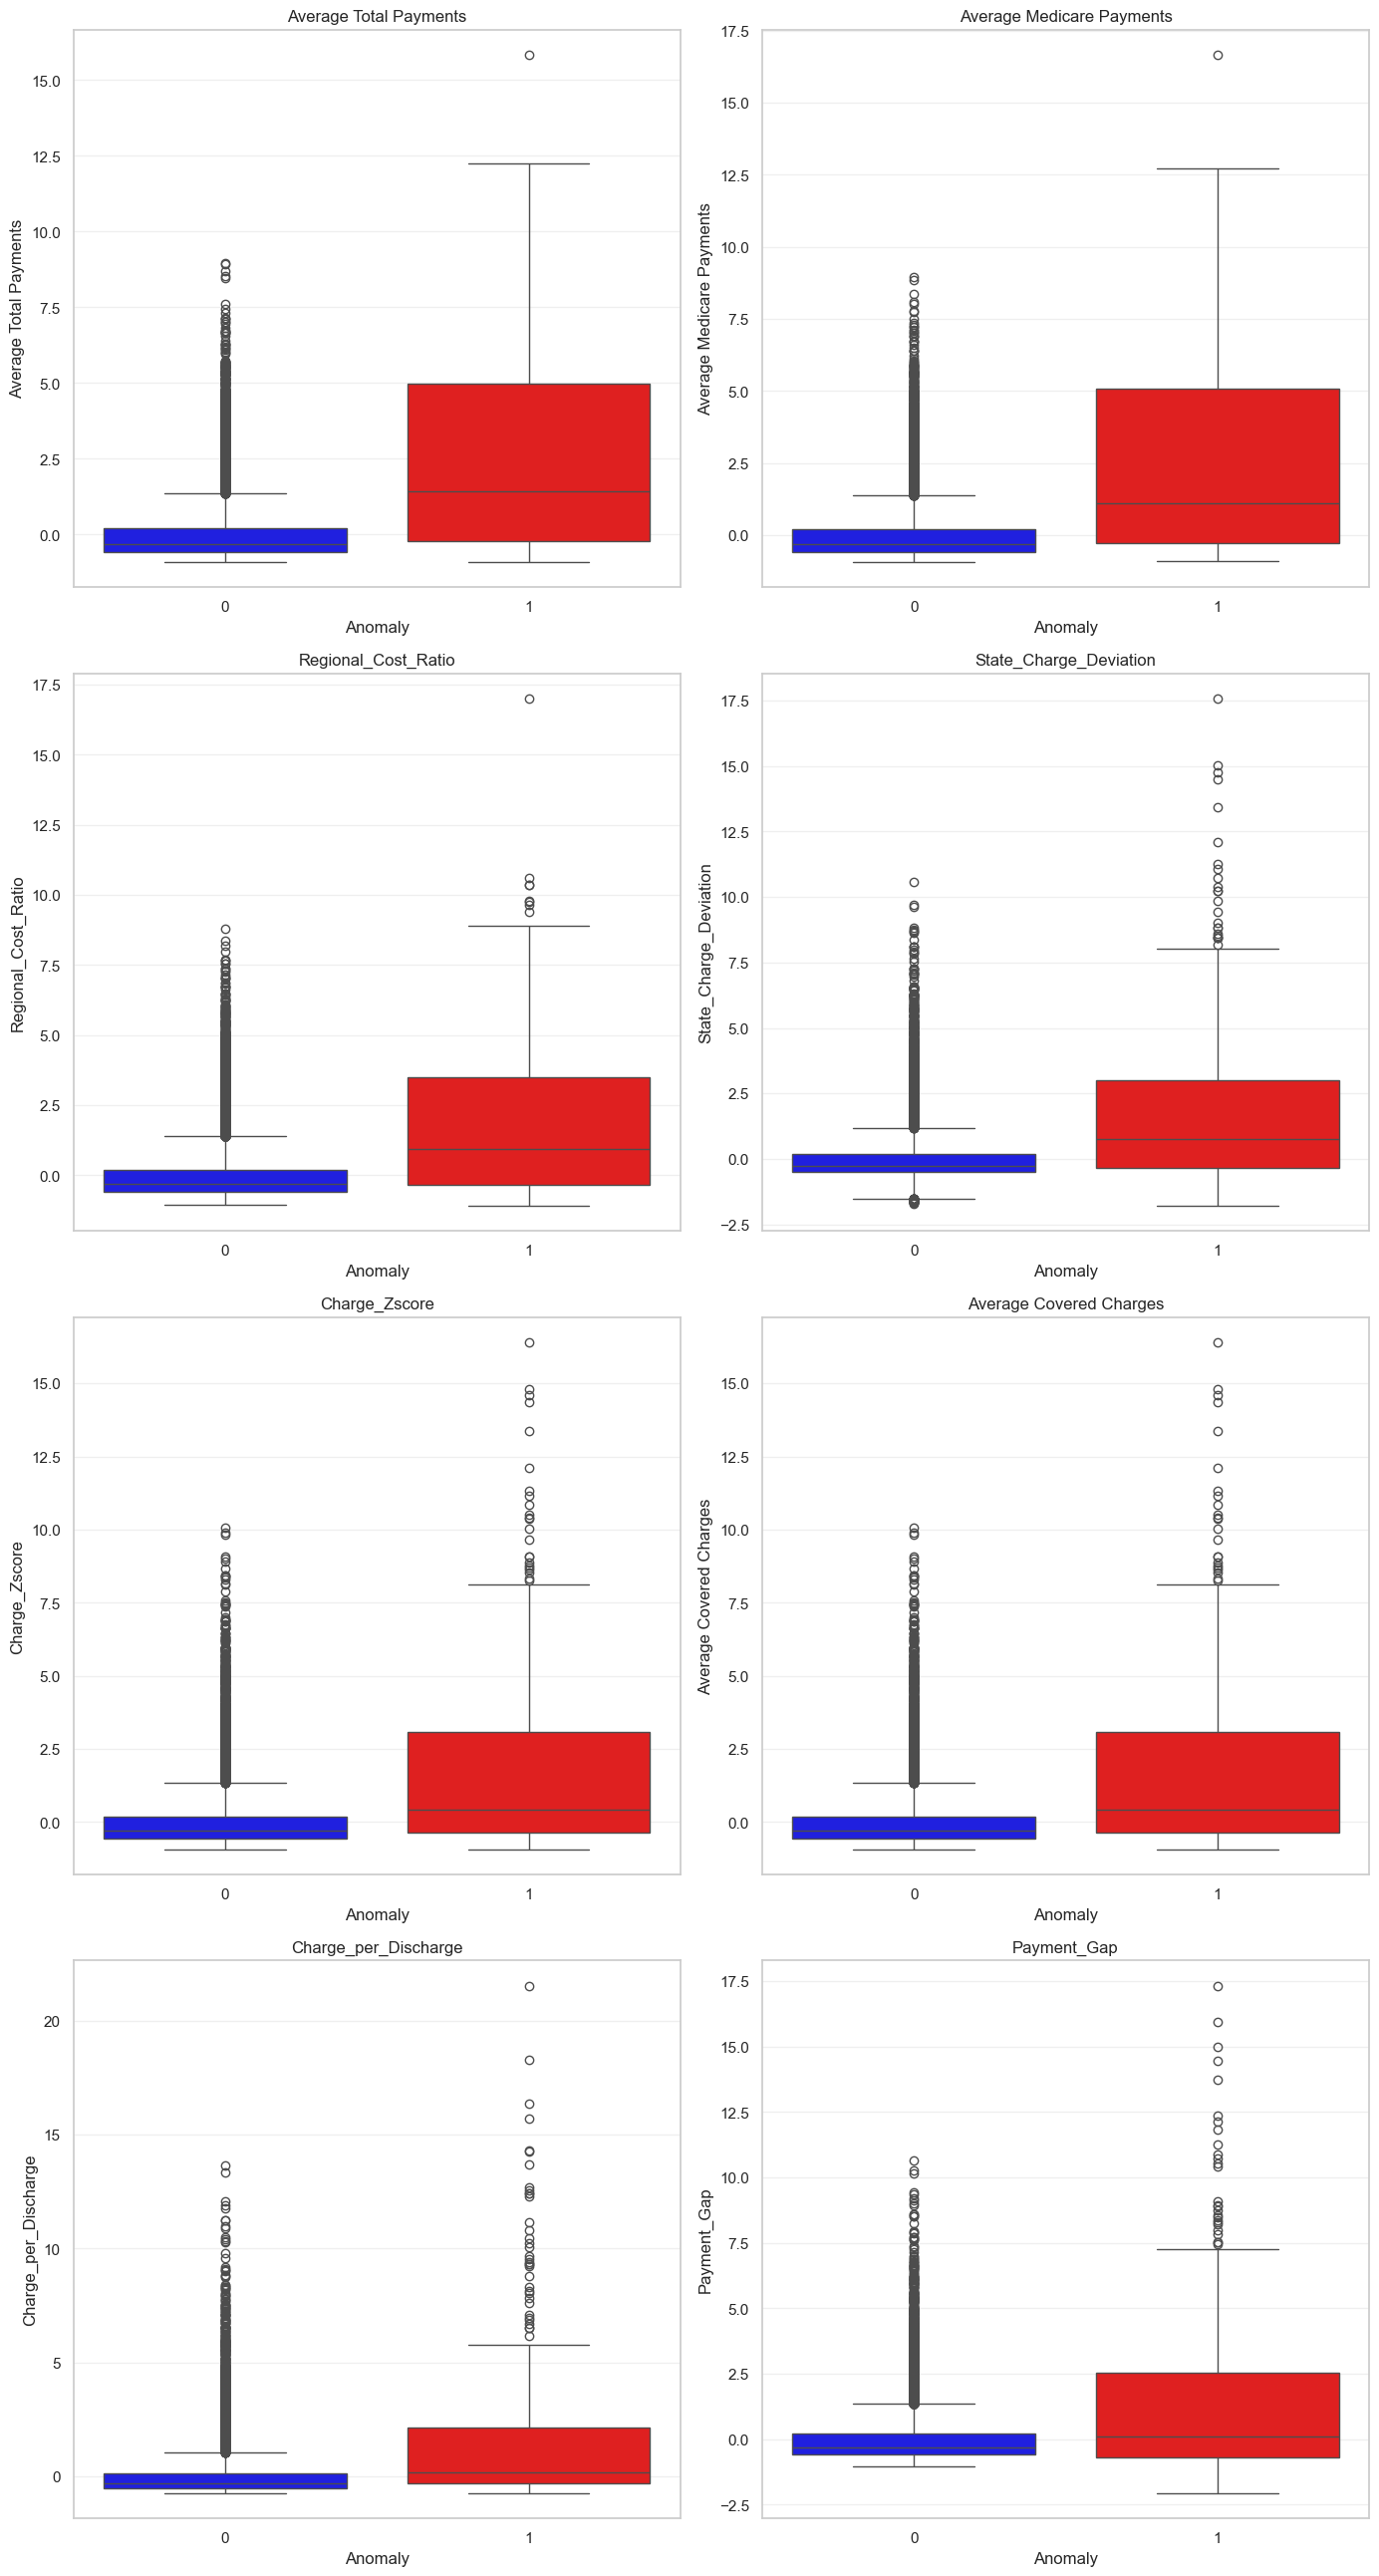

In [1291]:
plt.figure(figsize=(14, len(top_features) * 4))

for i, col in enumerate(top_features):
    plt.subplot(len(top_features)//2 + 1, 2, i + 1)
    
    sns.boxplot(
        data=X_test_with_anomaly,
        x='Anomaly',
        y=col,
        palette=['blue', 'red']
    )
    
    plt.title(col)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Box plots are used to compare normal (inliers) and anomalous (outliers) records to justify why certain records are identified as anomalies based on their data values.

Average Total Payments and Average Medicare Payments show that anomalous records are concentrated at much higher values compared to normal records, indicating significantly higher payment levels.

State_Charge_Deviation and Regional_Cost_Ratio also show that anomalies remain higher even after adjusting for state and regional averages, confirming deviation from local pricing patterns. 

Charge_Zscore and Average Covered Charges indicate strong deviation from overall data distribution, with anomalies showing extreme positive values.

Payment_Gap and Charge_per_Discharge further show that anomalous records have larger differences between charges and payments and higher cost per discharge. 

Overall, the box plots clearly show a consistent separation between normal and anomalous records across key financial features.

## PCA Visualization of Inliers and Outliers

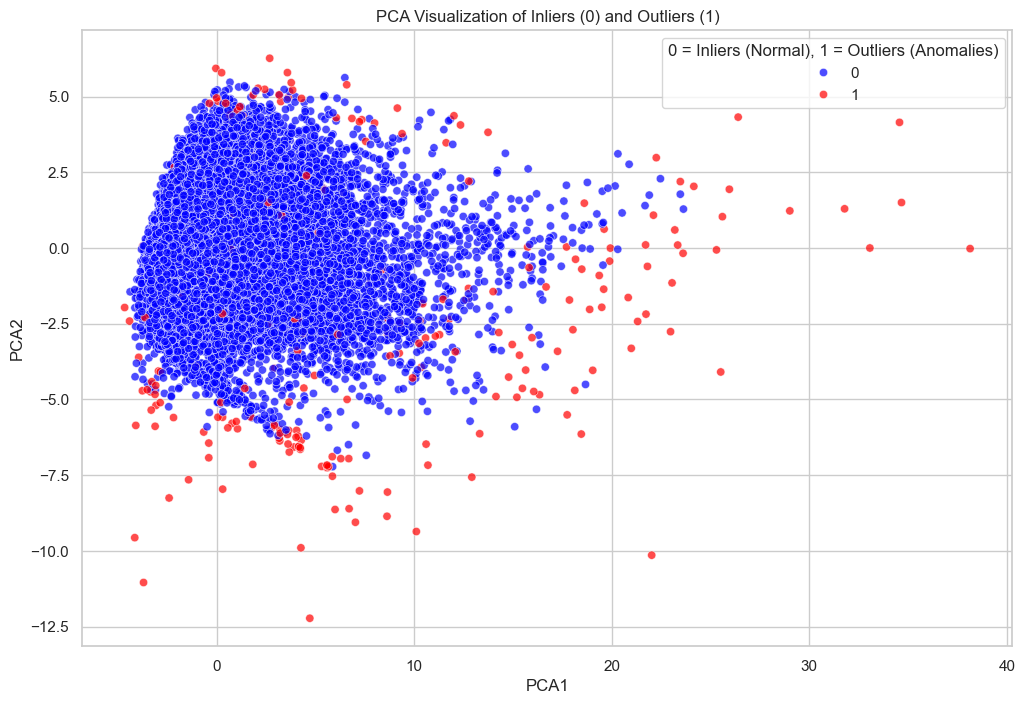

In [1309]:
pca = PCA(n_components=2)

pca.fit(X_train)

pca_result = pca.transform(X_test)

pca_df = pd.DataFrame()

pca_df['PCA1'] = pca_result[:,0]
pca_df['PCA2'] = pca_result[:,1]
pca_df['Anomaly'] = error_df['Anomaly'].values

plt.figure(figsize=(12,8))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Anomaly',
    data=pca_df,
    palette=['blue', 'red'],
    alpha=0.7
)

plt.title("PCA Visualization of Inliers (0) and Outliers (1)")

plt.legend(title="0 = Inliers (Normal), 1 = Outliers (Anomalies)")

plt.show()

#### Blue points represent inliers (normal records) and red points represent outliers (anomalies).

The PCA plot shows the distribution of inliers (0) and outliers (1) after reducing the dataset to two principal components (PCA1 and PCA2) for visualization.

Most inlier points form a dense cluster, showing that normal records share similar patterns in the reduced feature space. This indicates that the majority of the data follows a consistent structure.

The outlier points are more spread out and appear away from the main inlier cluster in several areas of the plot. This shows that these records are different from the main group in terms of their feature values.

Some outliers appear close to the inlier cluster, while others are clearly separated. This suggests that anomaly patterns vary in strength, with some being mild deviations and others being more distinct.

Overall, the PCA visualization provides a simplified view of the data and shows that the detected anomalies are not concentrated within the main cluster of normal records.

## Top Anomalies

In [1299]:
top_anomalies = error_df.sort_values(
    by='Reconstruction_Error',
    ascending=False
).head(20)

top_anomalies

,Reconstruction_Error,Anomaly
378,0.135884,1
31785,0.088481,1
11420,0.083203,1
8343,0.044348,1
10673,0.017841,1
4944,0.016583,1
32579,0.015578,1
10917,0.012951,1
10027,0.012214,1
18786,0.011114,1


## Final Anomaly Summary

In [1302]:
summary_df = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Detected Anomalies',
        'Anomaly Percentage'
    ],
    'Value': [
        total_count,
        anomaly_count,
        f"{round(anomaly_percentage,2)}%"
    ]
})

summary_df

,Metric,Value
0,Total Records,32613
1,Detected Anomalies,327
2,Anomaly Percentage,1.0%
